# Movie Recommender — Training Notebook

## 1. Load Data

In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from keras import layers
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, f1_score, confusion_matrix

ratings = pd.read_csv("data/ratings.csv")
movies = pd.read_csv("data/movies.csv")

print("ratings:", ratings.shape)
print("movies:", movies.shape)
ratings.head()

ratings: (100836, 4)
movies: (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## 2. Cleaning

In [ ]:
# Xóa các dòng có giá trị bị thiếu (NaN) trong bất kỳ cột nào
ratings.dropna(inplace=True)
movies.dropna(inplace=True)
# Xóa các dòng bị trùng lặp hoàn toàn
ratings.drop_duplicates(inplace=True)
movies.drop_duplicates(inplace=True)
ratings.reset_index(drop=True, inplace=True)
movies.reset_index(drop=True, inplace=True)

# Đếm số lượng ratings mỗi phim nhận được
movie_counts = ratings["movieId"].value_counts()


valid_movies = movie_counts[movie_counts >= 5].index
ratings = ratings[ratings["movieId"].isin(valid_movies)]


user_counts = ratings["userId"].value_counts()
valid_users = user_counts[user_counts >= 5].index
ratings = ratings[ratings["userId"].isin(valid_users)]

# Reset index sau khi lọc (tránh index bị nhảy cóc)
ratings.reset_index(drop=True, inplace=True)

# Lưu file sau khi đã làm sạch VÀ lọc noise
ratings.to_csv("data/ratings_clean.csv", index=False)
movies.to_csv("data/movies_clean.csv", index=False)

print("After noise removal — ratings:", ratings.shape)
print("After noise removal — movies:", movies.shape)

After noise removal — ratings: (90274, 6)
After noise removal — movies: (9742, 3)


## 3. EDA

In [6]:
# Xem kiểu dữ liệu từng cột và số lượng giá trị không null
print(ratings.info())

# Thống kê mô tả: min, max, mean, std, ... của từng cột số
ratings.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90274 entries, 0 to 90273
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   userId     90274 non-null  int64  
 1   movieId    90274 non-null  int64  
 2   rating     90274 non-null  float64
 3   timestamp  90274 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 2.8 MB
None


,userId,movieId,rating,timestamp
count,90274.000000,90274.000000,90274.000000,9.027400e+04
mean,321.462104,16284.192879,3.537358,1.198616e+09
std,181.825689,31375.602906,1.029858,2.161444e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,171.000000,1084.000000,3.000000,1.004408e+09
50%,318.000000,2692.000000,3.500000,1.180447e+09
75%,474.000000,6711.000000,4.000000,1.431969e+09
max,610.000000,187595.000000,5.000000,1.537799e+09


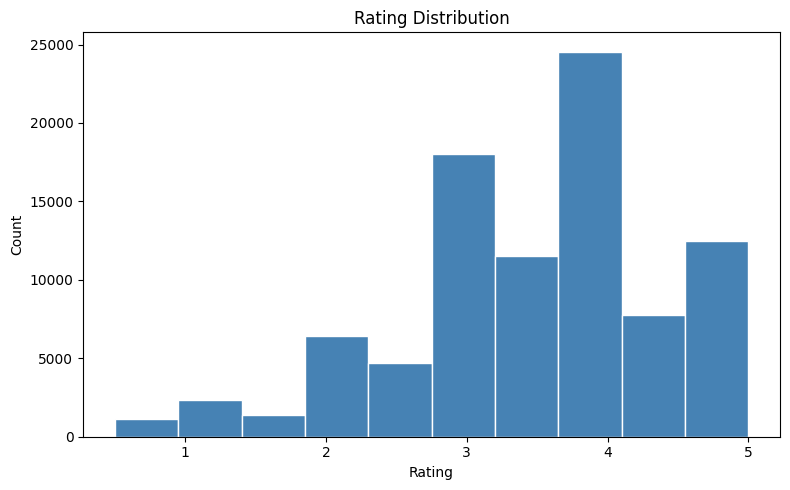

In [7]:
# Vẽ biểu đồ histogram phân phối điểm rating
plt.figure(figsize=(8, 5))
plt.hist(ratings["rating"], bins=10, color="steelblue", edgecolor="white")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 4. User-Item Matrix

In [8]:
# Tạo bảng pivot: hàng = userId, cột = movieId, giá trị = rating
# Ô nào user chưa xem phim đó sẽ là NaN
user_item_matrix = ratings.pivot_table(index="userId", columns="movieId", values="rating")

print("Matrix shape:", user_item_matrix.shape)  # (số user, số phim)
user_item_matrix.iloc[:10, :10]                  # xem 10x10 góc trên trái

Matrix shape: (610, 3650)


movieId,1,2,3,4,5,6,7,8,9,10
userId,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,4.0,5.0,3.0,5.0,4.0,4.0,3.0,NaN,3.0
7,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Sparsity

In [9]:
num_users_temp  = ratings["userId"].nunique()   # số user duy nhất
num_movies_temp = ratings["movieId"].nunique()  # số phim duy nhất

# Sparsity = tỉ lệ ô TRỐNG trong ma trận user-item
# = 1 - (số ratings thực tế / tổng số ô có thể có)
sparsity = 1 - (len(ratings) / (num_users_temp * num_movies_temp))

print(f"Users: {num_users_temp} | Movies: {num_movies_temp}")
print(f"Sparsity: {sparsity:.4f} ({sparsity*100:.2f}%)")
# Ví dụ: 98.5% nghĩa là 98.5% cặp (user, phim) chưa có rating

Users: 610 | Movies: 3650
Sparsity: 0.9595 (95.95%)


## 6. Encoding
Chuyển `userId` và `movieId` (dạng số nguyên bất kỳ) thành **chỉ số liên tục** bắt đầu từ 0.  
**Lý do:** Layer `Embedding` của Keras yêu cầu input là index liên tục `0, 1, 2, ...` — không chấp nhận ID tùy ý như `userId=138492`.


In [10]:
# Lấy danh sách tất cả userId và movieId duy nhất
user_ids  = ratings["userId"].unique().tolist()
movie_ids = ratings["movieId"].unique().tolist()

# Tạo dictionary ánh xạ: ID gốc → index liên tục
user2encoded  = {x: i for i, x in enumerate(user_ids)}
movie2encoded = {x: i for i, x in enumerate(movie_ids)}

# Ánh xạ ngược: index → movieId gốc (dùng khi decode kết quả)
encoded2movie = {i: x for i, x in enumerate(movie_ids)}

# Thêm cột encoded vào DataFrame để dùng khi train
ratings["user"]  = ratings["userId"].map(user2encoded)
ratings["movie"] = ratings["movieId"].map(movie2encoded)

print(f"Unique users: {len(user_ids)} | Unique movies: {len(movie_ids)}")
ratings[["userId","movieId","user","movie","rating"]].head()

Unique users: 610 | Unique movies: 3650


,userId,movieId,user,movie,rating
0,1,1,0,0,4.0
1,1,3,0,1,4.0
2,1,6,0,2,4.0
3,1,47,0,3,5.0
4,1,50,0,4,5.0


## 7. Normalize Ratings
Chuẩn hóa điểm rating về khoảng `[0, 1]` bằng **Min-Max Scaling**.  
**Lý do:** Output layer của model dùng `sigmoid` trả về giá trị trong `[0,1]` — nếu target (y) không cùng thang đo thì loss sẽ rất lớn và model khó hội tụ.

In [11]:
min_rating = ratings["rating"].min()  # điểm thấp nhất 
max_rating = ratings["rating"].max()  # điểm cao nhất 

# Công thức Min-Max: x_scaled = (x - min) / (max - min)
#  0.5 thành 0.0,  5.0  thành 1.0
ratings["rating"] = (ratings["rating"] - min_rating) / (max_rating - min_rating)

print(f"Rating range after normalization: [{ratings['rating'].min()}, {ratings['rating'].max()}]")

Rating range after normalization: [0.0, 1.0]


## 8. Build Dataset & Train/Test Split

In [12]:
# X: ma trận input gồm 2 cột [user_encoded, movie_encoded]
# Mỗi dòng là 1 cặp (user, phim) mà user đã xem
X = ratings[["user", "movie"]].values.astype(np.int32)

# y: nhãn — điểm rating đã normalize, model sẽ học dự đoán giá trị này
y = ratings["rating"].values.astype(np.float32)

# Chia 80% để train, 20% để đánh giá
# random_state=42 đảm bảo kết quả tái lặp được (reproducible)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

X_train: (72219, 2)
X_test:  (18055, 2)


## 9. Define Model

In [13]:
# Số chiều của vector embedding — càng lớn càng nhiều thông tin nhưng tốn tài nguyên hơn
EMBEDDING_SIZE = 50

class RecommenderNet(tf.keras.Model):

    def __init__(self, num_users, num_movies):
        super().__init__()

        # Mỗi user được biểu diễn bằng 1 vector 50 chiều
        # Model sẽ tự học vector này sao cho dự đoán rating chính xác nhất
        self.user_embedding  = layers.Embedding(num_users,  EMBEDDING_SIZE, name="user_embedding")

        # Tương tự cho phim — vector 50 chiều mô tả "đặc trưng ẩn" của phim
        self.movie_embedding = layers.Embedding(num_movies, EMBEDDING_SIZE, name="movie_embedding")

        # Bias user: bắt được xu hướng user đó thường cho điểm cao hay thấp
        self.user_bias  = layers.Embedding(num_users,  1)

        # Bias movie: bắt được mức độ phổ biến của phim (phim hay → bias dương)
        self.movie_bias = layers.Embedding(num_movies, 1)
        self.dropout = layers.Dropout(0.3)

    def call(self, inputs):
        # Lấy vector embedding tương ứng cho mỗi (user, movie) trong batch
        user_vector  = self.user_embedding(inputs[:, 0])   # shape: (batch, 50)
        movie_vector = self.movie_embedding(inputs[:, 1])  # shape: (batch, 50)
        user_bias    = self.user_bias(inputs[:, 0])        # shape: (batch, 1)
        movie_bias   = self.movie_bias(inputs[:, 1])       # shape: (batch, 1)
        # Áp dụng dropout lên embedding trước khi tính dot product
        user_vector  = self.dropout(user_vector)   # ← thêm dòng này
        movie_vector = self.dropout(movie_vector)  # ← thêm dòng này

        # Dot product: tính độ tương đồng giữa user và phim
        # Nếu 2 vector cùng chiều (sở thích khớp) → tích lớn → rating cao
        dot = tf.reduce_sum(user_vector * movie_vector, axis=1, keepdims=True)

        # Cộng bias rồi đưa qua sigmoid để ra xác suất trong [0, 1]
        return tf.nn.sigmoid(dot + user_bias + movie_bias)

# Khởi tạo model với số lượng user và phim thực tế trong dataset
model = RecommenderNet(len(user_ids), len(movie_ids))

# Compile: Adam optimizer + MSE loss (hồi quy điểm rating)
model.compile(optimizer="adam", loss="mse", metrics=["mae"])


## 10. Train

In [14]:
# Dừng training khi val_loss không cải thiện sau 3 epoch liên tiếp
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True  # khôi phục trọng số tốt nhất (epoch 2)
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],  # ← thêm dòng này
    verbose=1
)

Epoch 1/10
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0628 - mae: 0.2061 - val_loss: 0.0433 - val_mae: 0.1651
Epoch 2/10
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0364 - mae: 0.1489 - val_loss: 0.0362 - val_mae: 0.1467
Epoch 3/10
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0288 - mae: 0.1302 - val_loss: 0.0348 - val_mae: 0.1432
Epoch 4/10
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0227 - mae: 0.1144 - val_loss: 0.0348 - val_mae: 0.1431
Epoch 5/10
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0176 - mae: 0.0998 - val_loss: 0.0354 - val_mae: 0.1444
Epoch 6/10
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0137 - mae: 0.0870 - val_loss: 0.0363 - val_mae: 0.1464
Epoch 7/10
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0107 - mae: 0.0764 - val_loss: 0.0374 - val_mae: 0.1486


## 11. Evaluate
Đánh giá chất lượng mô hình trên tập test bằng các chỉ số hồi quy và phân loại.

In [15]:
# Dự đoán rating cho toàn bộ tập test
# .flatten() để chuyển từ shape (n,1) về (n,) cho dễ tính metric
y_pred = model.predict(X_test).flatten()

# MSE — Mean Squared Error: trung bình bình phương sai số

mse  = mean_squared_error(y_test, y_pred)

# RMSE — căn bậc 2 của MSE, cùng đơn vị với rating (dễ hiểu hơn MSE)
rmse = np.sqrt(mse)

# MAE — Mean Absolute Error: trung bình sai số tuyệt đối
mae  = mean_absolute_error(y_test, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step
MSE:  0.0348
RMSE: 0.1865
MAE:  0.1431


## 12. Loss Graph
Vẽ đường cong loss theo từng epoch để kiểm tra quá trình học của model.  

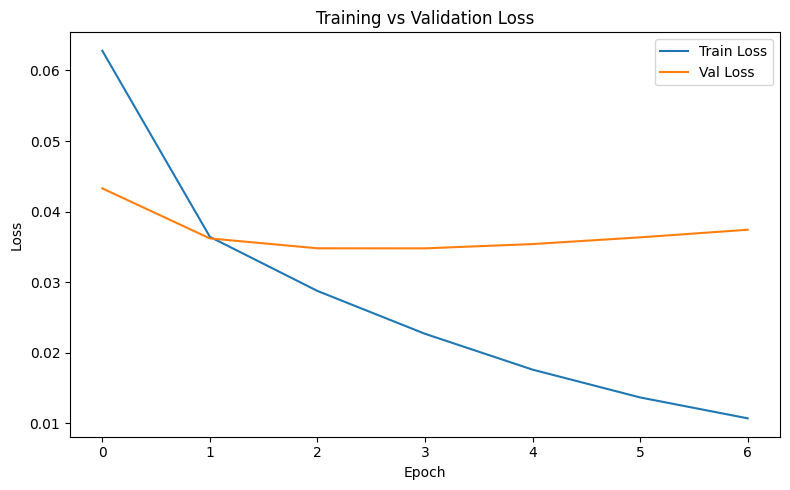

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"],     label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.tight_layout()
plt.show()

## 13. Save Artifacts

In [17]:
# Lưu trọng số model (không lưu cả model để tránh lỗi tương thích phiên bản Keras)
model.save_weights("model.weights.h5")
print("✅ Saved model weights")

# Lấy ma trận embedding của phim — shape: (số_phim, 50)
# Đây là "đặc trưng ẩn" của từng phim học được từ dữ liệu rating
# recommender.py dùng ma trận này để tính cosine similarity giữa các phim
movie_embeddings = model.get_layer("movie_embedding").get_weights()[0]
np.save("movie_embeddings.npy", movie_embeddings)
print("✅ Saved movie embeddings:", movie_embeddings.shape)

# Lưu 2 dictionary ánh xạ movieId ↔ index
# recommender.py cần để tìm đúng vector embedding của từng phim
with open("mappings.pkl", "wb") as f:
    pickle.dump({"movie2encoded": movie2encoded, "encoded2movie": encoded2movie}, f)
print("✅ Saved mappings")

✅ Saved model weights
✅ Saved movie embeddings: (3650, 50)
✅ Saved mappings
